## Installing the dependencies

`category_encoders`: Installed for `CatBoostEncoder` usage, for further info check out [category_encoders](https://contrib.scikit-learn.org/category_encoders/) and [CatBoostEncoder](https://contrib.scikit-learn.org/category_encoders/catboost)

In [1]:
!pip install category_encoders

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e9/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e9/train.csv
/kaggle/input/competitions/playground-series-s6e9/test.csv


## Importing the neccesarry libraries

#### Descriptions and Libraries:

`keras`: A famous DL framework used for creating DL models.

`tensorflow`: The main DL framework on top of the keras.

`matplotlib.pyplot`: Visualization and plotting library.

`seaborn`: Visualization and plotting library.

`math`: native python mathematical work library.

`sci-kit_learn` (sklearn): Optimization, pipelines, composing, preprocessing, folding and every preprocess step handler for ML.

`category_encoders`: Encoding the categorical values (for long and seep values).

In [3]:
import keras
from keras.models import Model
from keras import layers
import tensorflow as tf

import matplotlib.pyplot as plt
import seaborn as sns

import math

from category_encoders.cat_boost import CatBoostEncoder

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

#### Plot settings, finding the available styles and using one

In [4]:
#plt.style.available # useful for checking the available plt styles.
plt.style.use("seaborn-v0_8")

## Finding the device

In [5]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU Available: {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("WARNING: No GPU found! Check your notebook accelerator settings (e.g., Kaggle/Colab GPU setting).")

GPU Available: /physical_device:GPU:0


## Mini utility methods

### Descriptions:

num_cols: used for selecting numerical_columns, DRY (Don't repeat yourself) code.
cat_cols: used for selecting categorical_columns, DRY (Don't repeat yourself) code.

`feature_all_charge_stations`: feature code, new column that sums up charging stations near home and nearh work.

`feature_km_by_car`: feature code, new column for calculating the km usage per car.

`feature_annual_income_digits`: feature code, new column for each digit of the `Annual_Income_USD`.

`feature_daily_commute_km_digits`: feature code, new column for each digit of the `Daily_Commute_km`.

In [6]:
def num_cols(data) -> list:
    return data.select_dtypes(include=np.number).columns.tolist()

def cat_cols(data) -> list:
    return data.select_dtypes(exclude=np.number).columns.tolist()

def feature_all_charge_stations(data, return_columns:bool=False, copy:bool=False) -> pd.DataFrame | tuple[pd.DataFrame, list, list]:
    if copy:
        data = data.copy(True)
    data["all_charge_stations"] = data["Charging_Stations_Near_Home"] + data["Charging_Stations_Near_Work"]
    if return_columns:
        numerical_columns = num_cols(data)
        categorical_columns = cat_cols(data)
        return data, numerical_columns, categorical_columns
    return data

def feature_km_by_car(data, return_columns:bool=False, copy:bool=False) -> pd.DataFrame | tuple[pd.DataFrame, list, list]:
    if copy:
        data = data.copy(True)
    data["km_by_car"] = data["Daily_Commute_km"] / data["Number_of_Cars_Owned"].replace(0, np.nan)
    if return_columns:
        numerical_columns = num_cols(data)
        categorical_columns = cat_cols(data)
        return data, numerical_columns, categorical_columns
    return data

def feature_annual_income_digits(data, return_columns:bool=False, copy:bool=False) -> pd.DataFrame | tuple[pd.DataFrame, list, list]:
    if copy:
        data = data.copy()
        
    income = data['Annual_Income_USD'].fillna(0).astype(int)
    data['digit_100k'] = ((income // 100_000) % 10).astype(str)
    data['digit_10k']  = ((income // 10_000) % 10).astype(str)
    data['digit_1k']   = ((income // 1_000) % 10).astype(str)
    data['digit_100s'] = ((income // 100) % 10).astype(str)

    data[['digit_100k', 'digit_10k', 'digit_1k', 'digit_100s']] = data[['digit_100k', 'digit_10k', 'digit_1k', 'digit_100s']].astype('category')

    if return_columns:
        numerical_columns = num_cols(data)
        categorical_columns = cat_cols(data)
        return data, numerical_columns, categorical_columns
    return data

def feature_daily_commute_km_digits(data, return_columns:bool=False, copy:bool=False) -> pd.DataFrame | tuple[pd.DataFrame, list, list]:
    if copy:
        data = data.copy()

    daily_com = data['Daily_Commute_km'].fillna(0).astype(int)

    data["digit_100"] = ((daily_com // 100) % 10).astype(str)
    data["digit_10"] = ((daily_com // 10) % 10).astype(str)
    data["digit_1"] = ((daily_com // 1) % 10).astype(str)
    
    if return_columns:
        numerical_columns = num_cols(data)
        categorical_columns = cat_cols(data)
        return data, numerical_columns, categorical_columns
    return data

# Loading the data

Handling feature engineering and other variables, removing the target from columns and calculating unique count of cateogrical columns (used for finding which encoding method is useful)

In [7]:
train_df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/train.csv", index_col=0)
test_df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/test.csv", index_col=0)

feature_all_charge_stations(train_df)
feature_km_by_car(train_df)
feature_all_charge_stations(test_df)
feature_km_by_car(test_df)
feature_annual_income_digits(train_df)
feature_annual_income_digits(test_df)
feature_daily_commute_km_digits(train_df)
feature_daily_commute_km_digits(test_df)

numerical_columns = num_cols(train_df)
categorical_columns = cat_cols(train_df)
target = "Will_Buy_EV"

if target in numerical_columns:
    numerical_columns.remove(target)
    
if target in categorical_columns:
    categorical_columns.remove(target)

for col in categorical_columns:
    train_df[col] = train_df[col].astype(object).fillna("Missing").astype(str)
    test_df[col] = test_df[col].astype(object).fillna("Missing").astype(str)

total_cat = train_df[categorical_columns].nunique().sum()
print(f"Total Categorical unique values:\n{total_cat - 2}\n")

train_df.info()

Total Categorical unique values:
68

<class 'pandas.core.frame.DataFrame'>
Index: 668665 entries, 0 to 668664
Data columns (total 23 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Age                          668665 non-null  int64  
 1   Annual_Income_USD            668665 non-null  float64
 2   Daily_Commute_km             668665 non-null  float64
 3   Number_of_Cars_Owned         668665 non-null  int64  
 4   Charging_Stations_Near_Home  668665 non-null  int64  
 5   Charging_Stations_Near_Work  668665 non-null  int64  
 6   Environmental_Concern_Level  668665 non-null  float64
 7   Gender                       668665 non-null  object 
 8   City_Type                    668665 non-null  object 
 9   Current_Car_Type             668665 non-null  object 
 10  Home_Charging_Possible       668665 non-null  object 
 11  Subsidy_Available            668665 non-null  object 
 12  Range_Anxiety_Level       

#### Based off of the skedewness we are going to use `Embedding`

## Plotting the data

Plotting the categorical_columns using barplot.
Plotting the numerical_columns using histplot, checking the correlation between numerical values using heatmap.

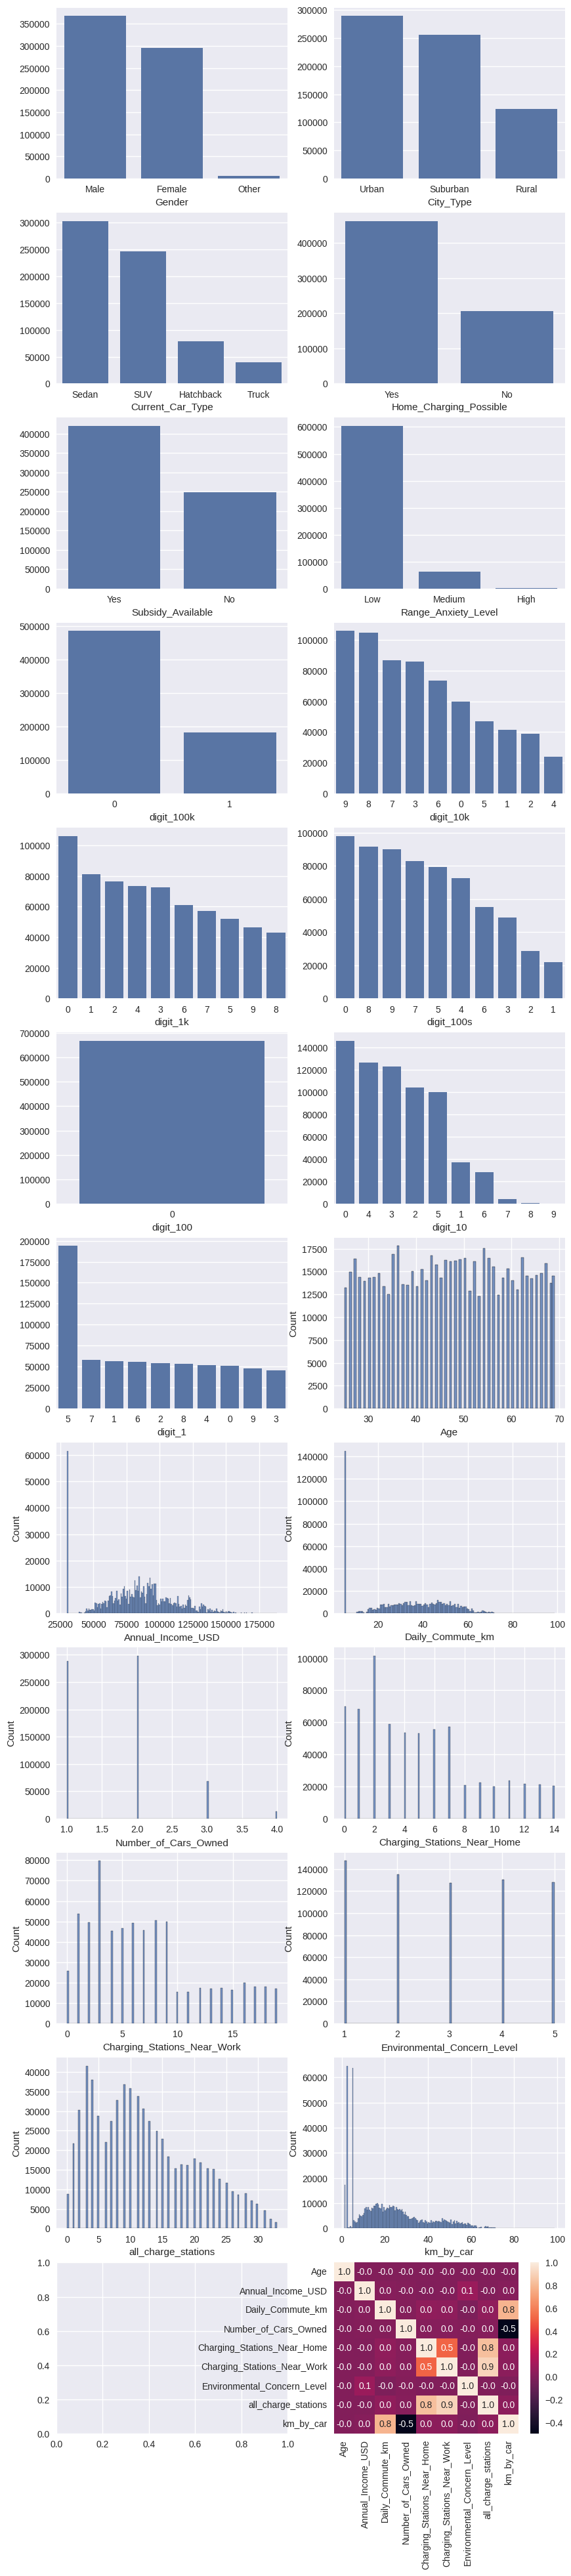

In [8]:
row_num = math.ceil((len(numerical_columns) + len(categorical_columns) + 1) / 2)
fig, ax = plt.subplots(nrows=row_num, ncols=2, figsize=(10, row_num * 4), squeeze=False)
axes_flat = ax.ravel()

for i, column in enumerate(categorical_columns):
    counts = train_df[column].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=axes_flat[i])

for j, column in enumerate(numerical_columns):
    index_for_ax = len(categorical_columns) + j
    sns.histplot(train_df[column], ax=axes_flat[index_for_ax])

sns.heatmap(train_df[numerical_columns].corr(), annot=True, fmt=".1f")

plt.show()

# Model

## Defiining an automated model creator

`model_create`: given the input layer as `keras.layers.Input` it automatically creates a model with `Dense`, `BatchNormalization`, `LeakyReLU` and `Dropout` layers. 

### Parameters:

`inputs`: takes `list` as its input, for the model

`x_tensor`: The tensor that is going to be passed to the dense layers.

`*hidden`: `int` where you don't spesifiy kew values and any input given here turns into another full layer.

`output_layer`: Currently only works with binary classification, takes `int` as input

`return_model`: `bool` wheter to return as model or as a tuple

In [9]:
def model_create(inputs, x_tensor, *hidden, output_layer=1, return_model: bool = True):
    """
    inputs: Raw Input layer OR list of Input layers (e.g., inputs)
    x_tensor: The tensor to pass into the dense layers (e.g., combined)
    """
    x = x_tensor
    for units in hidden:
        x = layers.Dense(units)(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU()(x)
        x = layers.Dropout(0.5)(x)

    x = layers.Dense(output_layer)(x)
    if return_model:
        return Model(inputs=inputs, outputs=x)
    return inputs, x

## Starting the categorical encoding.

In [10]:
inputs = []
embeddings = []

for column in categorical_columns:
    col_input = layers.Input(shape=(1,), dtype=tf.string, name=column)
    inputs.append(col_input)
    
    lookup = layers.StringLookup(mask_token=None)
    lookup.adapt(train_df[column].values)
    
    n_tokens = lookup.vocabulary_size()
    embedding_dim = min(50, max(2, int(np.ceil(n_tokens / 2))))
    
    embed_layer = layers.Embedding(input_dim=n_tokens, output_dim=embedding_dim)
    
    x = lookup(col_input)
    x = embed_layer(x)
    x = layers.Flatten()(x)
    
    embeddings.append(x)

all_categorical_features = layers.concatenate(embeddings)

I0000 00:00:1788691282.161059      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788691282.167241      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## Starting the numerical input.

In [11]:
num_imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

train_num_imputed = num_imputer.fit_transform(train_df[numerical_columns])
train_num_scaled = scaler.fit_transform(train_num_imputed)

num_input = layers.Input(shape=(len(numerical_columns),), dtype=tf.float32, name="numerical")
inputs.append(num_input)

## Combining the numerical and categorical values

In [12]:
combined = layers.concatenate([all_categorical_features, num_input])

## Defining the model

In [13]:
model = model_create(inputs, combined, 128, 128, 128, 128, 128, output_layer=1)
model.compile(optimizer="adam", loss=tf.keras.losses.BinaryCrossentropy(from_logits=True), metrics=["accuracy"])

# Setting the final data

In [14]:
X_train = {col: train_df[col].values.astype(object) for col in categorical_columns}
X_train["numerical"] = train_num_scaled.astype(np.float32)

le = LabelEncoder()
y_train = le.fit_transform(train_df[target])

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))

batch_size = 512
train_ds = train_ds.shuffle(buffer_size=len(y_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

## Fitting the model

In [15]:
model.fit(train_ds, epochs=5)

Epoch 1/5
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - accuracy: 0.8628 - loss: 0.2831
Epoch 2/5
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.8777 - loss: 0.2445
Epoch 3/5
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.8817 - loss: 0.2401
Epoch 4/5
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.8839 - loss: 0.2383
Epoch 5/5
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.8849 - loss: 0.2371


# Predicting the test DataFrame

## Setting the test dataset

In [16]:
test_num_imputed = num_imputer.transform(test_df[numerical_columns])
test_num_scaled = scaler.transform(test_num_imputed)

X_test = {col: test_df[col].values.astype(object) for col in categorical_columns}
X_test["numerical"] = test_num_scaled.astype(np.float32)

test_ds = tf.data.Dataset.from_tensor_slices(X_test).batch(batch_size).prefetch(tf.data.AUTOTUNE)

## Predicting the test dataset

In [17]:
logits = model.predict(test_ds)

560/560 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


# Results

## Converting results into csv file

In [18]:
results = pd.DataFrame(
    logits,
    index=test_df.index,
    columns=[target]
)

print(results[target].describe())

results.to_csv("submission.csv")

print(results.info())

count    286571.000000
mean         -4.027649
std           3.612758
min         -18.882460
25%          -6.325103
50%          -3.924681
75%          -1.052503
max           3.041414
Name: Will_Buy_EV, dtype: float64
<class 'pandas.core.frame.DataFrame'>
Index: 286571 entries, 668665 to 955235
Data columns (total 1 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Will_Buy_EV  286571 non-null  float32
dtypes: float32(1)
memory usage: 3.3 MB
None
